In [19]:
# Bootstrap: thêm project root vào sys.path
# (cần thiết khi chạy từ research/ — 3 cấp dưới project root)
import sys
from pathlib import Path

_ROOT = Path().resolve().parent.parent.parent  # research/ → combo/ → strategies/ → root
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))


# Combo Strategy — Backtest Notebook
**Trend Following | H4 | 7 Indices | FTMO**

Chạy từng cell theo thứ tự `Shift+Enter`.

> **Thông số chiến lược** (kTP, x, MA, ...) load tự động từ `strategy_config.py`.  
> Để thay đổi → chỉnh `strategy_config.py`, rồi **Restart & Run All**.


In [20]:
# ==============================================================================
# CELL 1 — IMPORTS: Nạp tất cả thư viện và module cần dùng
# ==============================================================================
#
# MỤC ĐÍCH:
#   Cell này là "kho hàng" — tập trung tất cả những gì notebook cần vào một chỗ.
#   Chạy cell này trước, các cell sau mới dùng được.
#
# CÁC NHÓM IMPORT:
#
# ── 1. Thư viện hệ thống ─────────────────────────────────────────────────────
#   warnings  : tắt các cảnh báo không cần thiết (FutureWarning, DeprecationWarning,...)
#   sys       : thao tác với môi trường Python (đã dùng ở cell bootstrap)
#   logging   : ghi log — chỉ hiện WARNING trở lên, ẩn INFO/DEBUG
#   datetime  : thao tác với ngày giờ (không dùng trực tiếp nhiều nhưng tiện để import sẵn)
#
# ── 2. Thư viện dữ liệu ──────────────────────────────────────────────────────
#   pandas (pd)  : bảng dữ liệu — toàn bộ OHLCV, trade log, metrics đều là DataFrame
#   numpy  (np)  : tính toán số học nhanh (sqrt, nan, inf, array operations)
#
# ── 3. Vẽ đồ thị ─────────────────────────────────────────────────────────────
#   matplotlib.pyplot (plt)         : vẽ biểu đồ chính
#   matplotlib.gridspec             : tạo layout nhiều panel (ví dụ: chart + MACD + ATR)
#   matplotlib.colors               : tạo colormap tùy chỉnh (heatmap xanh-đỏ)
#   matplotlib.ticker.FuncFormatter : format trục y thành dạng $100,000
#   %matplotlib inline              : lệnh Jupyter để vẽ trực tiếp trong notebook
#   plt.rcParams['figure.dpi']=120  : độ phân giải 120dpi — sắc nét hơn mặc định (72dpi)
#
# ── 4. Kết nối database ───────────────────────────────────────────────────────
#   get_connection  : mở kết nối tới SQL Server (DWH)
#   test_connection : kiểm tra kết nối còn sống không
#
# ── 5. Cấu hình chiến lược (strategy_config.py) ───────────────────────────────
#   STRATEGY        : dict chứa các tham số chiến lược (risk%, kTP, min_rr,...)
#   _SYMBOLS        : dict chứa config từng symbol (x, session, contract_value,...)
#   US30_KEY        : tên key của US30 (dùng làm bộ lọc macro)
#   get_symbol_ktp  : hàm lấy kTP của từng symbol (có thể override per-symbol)
#   get_indicator_params : hàm trả về dict tham số các indicator (MA, MACD, ATR)
#   summary         : hàm in tóm tắt cấu hình chiến lược hiện tại
#
# ── 6. Backtest engine (backtest_engine.py) ──────────────────────────────────
#   load_backtest_data      : kéo dữ liệu OHLCV từ SQL Server
#   add_backtest_indicators : tính MA, MACD, ATR, prev_close, prev_ma trên dữ liệu
#   session_mask            : tạo mặt nạ lọc giờ trading
#   detect_signals          : quét tín hiệu BUY/SELL trên toàn bộ dữ liệu
#   backtest_symbol         : chạy mô phỏng lệnh bar-by-bar (engine chính)
#   calc_metrics            : tính toán các chỉ số hiệu suất từ trade log
#
# ── 7. Theme (theme.py) ──────────────────────────────────────────────────────
#   SIGNAL, DARK, EQUITY_COLORS : bảng màu cho biểu đồ (dark theme)
#   NUM_FMT, METRICS_FMT        : format số cho bảng (%, $, số thập phân)
#   style_signal_row, setup_dark_axes, setup_dark_figure : helper vẽ đồ thị
#   color_pf                    : tô màu cột Profit Factor (xanh/đỏ tùy giá trị)
#   dark_table_props            : style bảng dark theme
#
# ── Dòng cuối ─────────────────────────────────────────────────────────────────
#   strategy_summary() → in ra tóm tắt cấu hình đang dùng (MA=20, kTP=2.3,...)
#   để confirm ngay khi chạy cell xem params có đúng không.

import warnings

warnings.filterwarnings('ignore')

import logging
import sys
from datetime import datetime

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from modules.db_connector import get_connection, test_connection
from strategies.combo.core.backtest_engine import (
    add_backtest_indicators,
    backtest_symbol,
    calc_metrics,
    detect_signals,
    load_backtest_data,
    session_mask,
)
from strategies.combo.core.strategy_config import (
    STRATEGY,
    US30_KEY,
    get_indicator_params,
    get_symbol_ktp,
)
from strategies.combo.core.strategy_config import (
    SYMBOLS as _SYMBOLS,
)
from strategies.combo.core.strategy_config import (
    summary as strategy_summary,
)
from strategies.combo.core.theme import (
    DARK,
    EQUITY_COLORS,
    METRICS_FMT,
    NUM_FMT,
    SIGNAL,
    color_pf,
    dark_table_props,
    setup_dark_axes,
    setup_dark_figure,
    style_signal_row,
)

logging.basicConfig(level=logging.WARNING)

# In tóm tắt cấu hình — luôn verify params trước khi chạy backtest
print(strategy_summary())

Strategy     : Combo v2
Symbols      : US30, HK50, J225
US30 filter  : none
MA period    : 20
MACD         : (5, 25, 5)
ATR period   : 5
kTP          : 2.3
Min R:R      : 1.25


In [21]:
# ==============================================================================
# CELL 2 — THAM SỐ BACKTEST: Chỉnh ở đây trước khi chạy
# ==============================================================================
#
# MỤC ĐÍCH:
#   Đây là "bảng điều khiển" của toàn bộ backtest.
#   Mỗi lần muốn thử một kịch bản khác (khoảng thời gian khác, số vốn khác,
#   chi phí giao dịch khác), chỉ cần chỉnh các biến ở đây, rồi Restart & Run All.
#
# NGUYÊN TẮC THIẾT KẾ:
#   - Tham số chiến lược (kTP, MA, risk%) được giữ trong strategy_config.py
#     và load tự động — KHÔNG sửa ở đây để tránh sai lệch giữa backtest và live.
#   - Chỉ có các tham số BACKTEST-SPECIFIC mới nằm ở cell này:
#     tài khoản, khoảng thời gian, phí giao dịch, symbol preview.
#
# ── ACCOUNT ───────────────────────────────────────────────────────────────────
# INITIAL_BALANCE = 100,000 USD
#   Tổng vốn ban đầu của toàn bộ portfolio.
#   Vốn được chia đều cho từng symbol: 100,000 / 4 symbols = $25,000/symbol.
#   Tại sao chia đều? → Mỗi symbol chạy độc lập, risk 0.5% equity riêng của symbol đó.
#   → Thay bằng 10,000 cho FTMO Starter, hoặc 200,000 cho Funded Pro.
#
# ── BACKTEST WINDOW ───────────────────────────────────────────────────────────
# DATE_FROM = '2023-01-01'  →  Ngày bắt đầu tính kết quả backtest (3 năm IS)
# DATE_TO   = '2025-12-31'  →  Ngày kết thúc tính kết quả backtest
#
#   Dữ liệu TRƯỚC DATE_FROM vẫn được load (để tính đủ indicator — gọi là "warmup"),
#   nhưng KHÔNG được tính vào kết quả. Các nến warmup chỉ để "khởi động" MA/MACD/ATR.
#
#   TẠI SAO DÙNG 2023-2025?
#   → Đây là cửa sổ In-Sample (IS) chính để đánh giá chiến lược trên 3 năm dữ liệu.
#   → 2026 trở đi được giữ làm True OOS — chưa được "nhìn" trong quá trình phân tích.
#
# ── TRADING COSTS ─────────────────────────────────────────────────────────────
# SLIPPAGE_PTS = 2 points
#   Mô phỏng độ trượt giá khi lệnh được khớp thực tế.
#   Khi đặt lệnh BUY breakout tại 44,000 → thực tế vào lệnh tại 44,002.
#   Tương tự khi đóng lệnh khi SL hit: vào SL tại 43,900 → thoát thực tế 43,898.
#   → Con số 2 pts là ước tính bảo thủ cho H4. Scalping cần cao hơn.
#
# COMMISSION_USD_PER_LOT = $3.5/lot/side
#   Phí giao dịch = $3.5 mỗi lot mỗi chiều (vào + thoát = $7 roundtrip).
#   HIỆN TẠI: contract_value = 0 cho tất cả symbols → commission KHÔNG được tính.
#   → Để tính commission: cần điền đúng contract_value vào strategy_config.py.
#
# ── PREVIEW SYMBOL ────────────────────────────────────────────────────────────
# PREVIEW_SYMBOL = 'US30'
#   Symbol được hiển thị chi tiết ở các cell đơn lẻ (Cell 6-9, 11):
#   xem chart, xem số lượng tín hiệu, verify dữ liệu,...
#   Đổi thành 'UK100', 'HK50', 'J225' để xem symbol khác.
#   → Không ảnh hưởng đến cell chạy portfolio (Cell 12).
#
# ── LOAD TỪ STRATEGY_CONFIG ──────────────────────────────────────────────────
#   Các biến P, MA_PERIOD,... được gán lại từ strategy_config để tiện dùng
#   trong các cell sau mà không cần gọi lại hàm mỗi lần.
#   Đây là cách Python "cache" giá trị để code gọn hơn.

INITIAL_BALANCE = 100_000   # Tổng vốn ban đầu (USD) — chia đều cho 4 symbols

DATE_FROM = '2023-01-01'    # Bắt đầu cửa sổ backtest (3 năm IS)
DATE_TO   = '2025-12-31'    # Kết thúc cửa sổ backtest (để 2026 làm OOS)

SLIPPAGE_PTS           = 2      # Điểm trượt giá mỗi lần fill lệnh (cả vào và thoát SL)
COMMISSION_USD_PER_LOT = 3.5    # $3.5/lot/chiều = $7 roundtrip (cần contract_value > 0)

PREVIEW_SYMBOL = 'US30'   # Symbol xem chi tiết ở các cell đơn — không ảnh hưởng portfolio

# ── Tự động load từ strategy_config — KHÔNG chỉnh trực tiếp ──────────────────
P                   = get_indicator_params()   # dict toàn bộ tham số indicator
MA_PERIOD           = P['MA_PERIOD']           # = 20  (SMA 20 nến)
ATR_PERIOD          = P['ATR_PERIOD']          # = 5   (ATR Wilder 5 nến)
MACD_FAST           = P['MACD_FAST']           # = 5   (EMA nhanh)
MACD_SLOW           = P['MACD_SLOW']           # = 25  (EMA chậm)
MACD_SIGNAL         = P['MACD_SIGNAL']         # = 5   (EMA signal)
RISK_PER_TRADE      = STRATEGY['risk_per_trade']       # = 0.005 (0.5%/lệnh)
FTMO_DAILY_LIMIT    = STRATEGY['ftmo_daily_limit']     # = 0.05  (giới hạn lỗ ngày 5%)
FTMO_MAX_DD         = STRATEGY['ftmo_max_dd']          # = 0.10  (max drawdown 10%)
TRAILING_ACTIVATION = STRATEGY['trailing_activation']  # = 1.0   (kích hoạt trail tại 1R)
PENDING_TTL_BARS    = STRATEGY['pending_ttl_bars']     # = 3     (hủy pending sau 3 nến)
MIN_RR              = STRATEGY['min_rr']               # = 1.25  (RR tối thiểu để vào lệnh)

print(f'Backtest window : {DATE_FROM} → {DATE_TO}')


Backtest window : 2023-01-01 → 2025-12-31


In [22]:
# ==============================================================================
# CELL 3 — SYMBOL CONFIG: Xem lại cấu hình từng symbol trước khi chạy
# ==============================================================================
#
# MỤC ĐÍCH:
#   Hiển thị bảng tóm tắt cấu hình của tất cả 6 symbols đang backtest,
#   để bạn có thể verify trực quan trước khi chạy portfolio ở Cell 12.
#
# TẠI SAO QUAN TRỌNG?
#   Các tham số này ảnh hưởng TRỰC TIẾP đến số lượng lệnh và P&L:
#   - x    : buffer breakout (US30=10 pts, US500=1 pt) → entry/SL xa hay gần đỉnh/đáy nến
#   - ktp  : hệ số TP (TP = kTP × ATR) → TP xa hay gần entry
#   - session_hours : giờ nào được phép vào lệnh ([] = tất cả giờ)
#   - contract_value : 0 nghĩa là commission chưa được tính (cần verify với FTMO)
#
# CẢNH BÁO contract_value = 0: ─────────────────────────────────────────────
#   Dòng code `_hl_zero` tô đỏ các ô contract_value = 0 trong bảng.
#   → Đây là nhắc nhở: kết quả backtest hiện TẠI chưa tính commission.
#   → Khi trade live, commission sẽ ăn vào lợi nhuận thực tế.
#   → Cần điền đúng số contract_value của FTMO cTrader trước khi dùng số liệu.
#
# CỤ THỂ TỪNG CỘT:
#   symbol          : mã hiệu (key trong SYMBOLS dict)
#   label           : tên hiển thị đầy đủ (US30 Dow Jones,...)
#   x               : breakout buffer (points) — entry = high + x (BUY)
#   ktp             : hệ số TP — TP = kTP × ATR tính từ entry
#   session_hours   : list giờ UTC được phép scan tín hiệu ([] = không lọc)
#   contract_value  : giá trị 1 lot chuẩn (USD) — cần để tính lot size + commission
#   group           : nhóm thị trường (US, EU, ASIA)

TARGET_SYMBOLS = _SYMBOLS  # Dùng toàn bộ 6 symbols từ strategy_config

# Tạo bảng config dạng DataFrame để hiển thị trực quan
cfg_rows = []
for k, v in TARGET_SYMBOLS.items():
    cfg_rows.append({
        'symbol':          k,
        'label':           v['label'],
        'x':               v['x'],
        'ktp':             get_symbol_ktp(k),   # kTP của symbol (có thể khác global default)
        'session_hours':   str(v['session_hours_utc']),
        'contract_value':  v.get('contract_value', 0),
        'group':           v.get('group', ''),
    })
cfg_df = pd.DataFrame(cfg_rows).set_index('symbol')

# Hàm tô đỏ ô có contract_value = 0 → nhắc nhở chưa cấu hình commission
def _hl_zero(v):
    return f'color: {SIGNAL["sell"]}; font-weight:bold' if v == 0 else ''

# Hiển thị bảng với cảnh báo contract_value
display(cfg_df.style
    .map(_hl_zero, subset=['contract_value'])
    .set_properties(**dark_table_props())
    .set_caption('⚠  Verify contract_value với FTMO cTrader trước khi trade live')
)

,label,x,ktp,session_hours,contract_value,group
symbol,,,,,,
US30,US30 (Dow Jones),13.000000,2.800000,[],1.000000,US
HK50,HK50 (Hang Seng 50),8.000000,2.800000,[],1.000000,ASIA
J225,J225 (Nikkei 225),8.000000,1.800000,[],1.000000,ASIA


In [23]:
# ==============================================================================
# CELL 4 — KIỂM TRA KẾT NỐI DATABASE
# ==============================================================================
#
# MỤC ĐÍCH:
#   Kiểm tra xem Python có kết nối được tới SQL Server (DWH) không
#   TRƯỚC KHI chạy các cell load dữ liệu.
#
# TẠI SAO CẦN CELL NÀY?
#   Toàn bộ dữ liệu OHLCV (nến H4) nằm trong SQL Server.
#   Nếu kết nối bị lỗi (SQL Server chưa chạy, sai password, mạng...) →
#   các cell load dữ liệu sẽ báo lỗi không rõ ràng.
#   Cell này "fail sớm" với thông báo dễ hiểu thay vì lỗi khó đọc ở giữa chừng.
#
# CÁCH HOẠT ĐỘNG:
#   test_connection() thử mở kết nối và chạy một câu SELECT đơn giản.
#   → Trả về True nếu thành công, False nếu thất bại.
#
# NẾU BÁO LỖI:
#   1. Mở SQL Server Management Studio kiểm tra server đang chạy
#   2. Kiểm tra file config kết nối (connection string)
#   3. Kiểm tra VPN nếu server nằm trên mạng nội bộ/cloud

ok = test_connection()
print('✓ SQL Server connected' if ok else '✗ Connection FAILED — kiểm tra SQL Server')

[OK] SQL Server connected. 20 tables found in SEN/DWH/MART.
✓ SQL Server connected


In [24]:
# ==============================================================================
# CELL 5 — XÁC NHẬN HÀM ĐÃ LOAD
# ==============================================================================
#
# MỤC ĐÍCH:
#   Xác nhận rằng toàn bộ hàm cần dùng đã được import thành công từ Cell 1.
#
# TẠI SAO CÓ CELL NÀY?
#   Trước đây (phiên bản cũ), các hàm backtest được định nghĩa TRỰC TIẾP
#   trong notebook → logic bị trùng giữa nhiều notebook, khó maintain.
#
#   Hiện tại, toàn bộ logic đã được chuyển vào backtest_engine.py (một file
#   Python riêng biệt) → notebook chỉ IMPORT và GỌI hàm, không tự định nghĩa.
#
# LỢI ÍCH:
#   - Sửa logic một chỗ (backtest_engine.py) → tất cả notebook tự động nhận
#   - Dễ test, dễ version control
#   - Notebook gọn gàng, tập trung vào phân tích chứ không phải code
#
# CÁC HÀM ĐƯỢC IMPORT (từ backtest_engine.py):
#   load_backtest_data      → kéo OHLCV từ SQL Server
#   add_backtest_indicators → tính indicator (MA, MACD, ATR)
#   session_mask            → tạo mask lọc giờ giao dịch
#   detect_signals          → quét tín hiệu BUY/SELL toàn bộ dữ liệu
#   backtest_symbol         → engine mô phỏng lệnh chính
#   calc_metrics            → tính Sharpe, PF, MaxDD, Win Rate,...

print('✓ Functions loaded from backtest_engine.py')
print('  load_backtest_data, add_backtest_indicators, session_mask,')
print('  detect_signals, backtest_symbol, calc_metrics')

✓ Functions loaded from backtest_engine.py
  load_backtest_data, add_backtest_indicators, session_mask,
  detect_signals, backtest_symbol, calc_metrics


In [25]:
# ==============================================================================
# CELL 6 — TẢI DỮ LIỆU 1 SYMBOL (PREVIEW)
# ==============================================================================
#
# MỤC ĐÍCH:
#   Tải dữ liệu OHLCV từ SQL Server cho symbol PREVIEW_SYMBOL (mặc định: US30)
#   để kiểm tra trước khi chạy portfolio toàn bộ.
#   Cell này chỉ phục vụ việc XEM — không ảnh hưởng đến Cell 12 (chạy portfolio).
#
# LUỒNG XỬ LÝ:
#   1. cfg_prev = lấy config của PREVIEW_SYMBOL từ TARGET_SYMBOLS
#      → gồm: symbol_id (ID trong DB), x (buffer), session...
#
#   2. load_backtest_data(symbol_id, date_to=DATE_TO)
#      → Chạy câu SQL: SELECT TOP 60000+warmup bars từ DWH.Fact_OHLCV
#      → Sắp xếp theo ngày cũ → mới
#      → Trả về DataFrame với index là BarTime, cột: open, high, low, close, volume
#
#   3. df_raw['in_window'] = df_raw.index >= DATE_FROM
#      → Tạo cột boolean True/False đánh dấu từng nến:
#        True  = nến nằm trong cửa sổ backtest (DATE_FROM → DATE_TO)
#        False = nến warmup (không tính kết quả, chỉ dùng tính indicator)
#
# TẠI SAO CẦN WARMUP?
#   MA(20) cần 20 nến mới có giá trị đầu tiên.
#   MACD(5,25,5) cần tối thiểu 25 nến.
#   Nếu không có warmup, các indicator ở đầu cửa sổ sẽ = NaN → không có tín hiệu.
#
# OUTPUT HIỂN THỊ:
#   - Tổng số bars đã load (gồm cả warmup)
#   - Ngày đầu / ngày cuối của dữ liệu
#   - Số bars nằm trong cửa sổ backtest
#   - 5 bars đầu và 5 bars cuối để verify dữ liệu

cfg_prev = TARGET_SYMBOLS[PREVIEW_SYMBOL]   # Lấy config của symbol đang preview
df_raw   = load_backtest_data(cfg_prev['symbol_id'], date_to=DATE_TO)

print(f'Symbol  : {PREVIEW_SYMBOL}')
print(f'Total bars (incl warmup) : {len(df_raw)}')
print(f'Earliest : {df_raw.index[0]}')
print(f'Latest   : {df_raw.index[-1]}')

# Đánh dấu từng nến: có nằm trong cửa sổ backtest không?
# True  → nến này ĐƯỢC TÍNH vào kết quả
# False → nến warmup, chỉ dùng để tính indicator
df_raw['in_window'] = df_raw.index >= pd.Timestamp(DATE_FROM)
print(f'In-window: {df_raw["in_window"].sum()} bars  ({DATE_FROM} → {DATE_TO})')
print()
print('─── 5 bars đầu trong cửa sổ backtest ───')
display(df_raw[df_raw['in_window']].head())
print('─── 5 bars cuối ───')
display(df_raw.tail())

Symbol  : US30
Total bars (incl warmup) : 4639
Earliest : 2023-01-03 05:00:00
Latest   : 2025-12-30 21:00:00
In-window: 4639 bars  (2023-01-01 → 2025-12-31)

─── 5 bars đầu trong cửa sổ backtest ───


,open,high,low,close,volume,in_window
BarTime,,,,,,
2023-01-03 05:00:00,33339.0,33352.0,33019.0,33091.0,13295.0,True
2023-01-03 09:00:00,33088.0,33240.0,33073.0,33221.0,10885.0,True
2023-01-03 13:00:00,33220.0,33492.0,33170.0,33484.0,21981.0,True
2023-01-03 17:00:00,33483.0,33487.0,33216.0,33286.0,21247.0,True
2023-01-03 21:00:00,33287.0,33389.0,32841.0,32910.0,58697.0,True


─── 5 bars cuối ───


,open,high,low,close,volume,in_window
BarTime,,,,,,
2025-12-30 05:00:00,48475.1,48501.4,48460.0,48483.1,5013.0,True
2025-12-30 09:00:00,48483.6,48493.0,48458.0,48480.0,5098.0,True
2025-12-30 13:00:00,48479.5,48492.7,48411.8,48476.6,7294.0,True
2025-12-30 17:00:00,48477.1,48489.9,48432.7,48463.8,8579.0,True
2025-12-30 21:00:00,48464.3,48487.6,48297.3,48399.1,30319.0,True


In [26]:
# ==============================================================================
# CELL 7 — TÍNH INDICATORS CHO PREVIEW SYMBOL
# ==============================================================================
#
# MỤC ĐÍCH:
#   Tính toán các chỉ báo kỹ thuật (MA, MACD, ATR) trên dữ liệu OHLCV vừa load.
#   Sau bước này, mỗi nến sẽ có đủ thông tin để quyết định có tín hiệu không.
#
# CÁCH HOẠT ĐỘNG:
#   add_backtest_indicators(df_raw, P) làm 3 việc:
#
#   1. Tính SMA(20) → cột 'ma'
#      Đường trung bình đơn giản 20 nến H4 (~3 tuần giao dịch).
#      Dùng để xác định xu hướng và điều kiện crossover.
#
#   2. Tính MACD(5, 25, 5) → cột 'macd_h' (histogram)
#      macd_h = EMA_fast(5) − EMA_slow(25) − Signal(5)
#      Dương → momentum tăng, Âm → momentum giảm.
#      Dùng để xác nhận chiều hướng của tín hiệu.
#
#   3. Tính ATR(5) Wilder → cột 'atr'
#      Average True Range: đo độ biến động trung bình của nến.
#      Dùng để tính khoảng cách TP: TP = kTP × ATR từ entry.
#      Wilder ATR = EMA đặc biệt (nhẹ hơn so với ATR truyền thống).
#
#   4. Thêm 2 cột phụ (dùng trong detect_signals):
#      prev_close = close nến trước (để kiểm tra crossover MA)
#      prev_ma    = MA nến trước   (để kiểm tra crossover MA)
#
# TẠI SAO DÙNG WILDER ATR?
#   Wilder ATR nhất quán với cách tính trong MT4/MT5 và cTrader.
#   Nếu dùng ATR khác (pandas EMA thường), kết quả sẽ lệch so với platform thực.
#
# OUTPUT HIỂN THỊ:
#   win = df trong cửa sổ backtest (bỏ warmup)
#   In range của MA, MACD, ATR để verify giá trị hợp lý.
#   Hiển thị 10 bars cuối để xem dữ liệu sau khi tính indicator.

df_ind = add_backtest_indicators(df_raw, P)     # Tính MA, MACD, ATR, prev_close, prev_ma
win    = df_ind[df_ind['in_window']]            # Chỉ lấy bars trong cửa sổ backtest

print(f'Indicators tính xong  |  {len(win)} bars trong cửa sổ')
print(f'MA({MA_PERIOD})  range : {win["ma"].min():.2f} → {win["ma"].max():.2f}')
print(f'MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL}) histogram range : {win["macd_h"].min():.4f} → {win["macd_h"].max():.4f}')
print(f'ATR({ATR_PERIOD}) range : {win["atr"].min():.2f} → {win["atr"].max():.2f}')
print()
display(df_ind[df_ind['in_window']][['open','high','low','close','ma','macd_h','atr']].tail(10))

Indicators tính xong  |  4639 bars trong cửa sổ
MA(20)  range : 31926.90 → 48593.03
MACD(5,25,5) histogram range : -468.3475 → 822.2206
ATR(5) range : 43.55 → 1379.42



,open,high,low,close,ma,macd_h,atr
BarTime,,,,,,,
2025-12-29 10:00:00,48699.1,48721.4,48676.7,48693.6,48539.405,-15.466978,90.526991
2025-12-29 14:00:00,48694.2,48728.3,48651.2,48702.4,48556.250,-15.868729,87.841593
2025-12-29 18:00:00,48702.3,48711.2,48511.0,48547.7,48566.945,-43.300166,110.313274
2025-12-29 22:00:00,48547.9,48560.7,48387.4,48479.5,48571.050,-62.678529,122.910619
2025-12-30 02:00:00,48478.0,48560.6,48436.5,48484.8,48581.805,-62.837591,123.148495
2025-12-30 05:00:00,48475.1,48501.4,48460.0,48483.1,48583.545,-55.748207,106.798796
2025-12-30 09:00:00,48483.6,48493.0,48458.0,48480.0,48587.290,-46.478020,92.439037
2025-12-30 13:00:00,48479.5,48492.7,48411.8,48476.6,48590.225,-37.314128,90.131230
2025-12-30 17:00:00,48477.1,48489.9,48432.7,48463.8,48593.035,-30.813264,83.544984


In [28]:
# ==============================================================================
# CELL 8 — SESSION FILTER + PHÁT HIỆN TÍN HIỆU
# ==============================================================================
#
# MỤC ĐÍCH:
#   Áp dụng bộ lọc giờ giao dịch, sau đó quét toàn bộ dữ liệu để tìm
#   tín hiệu BUY/SELL đáp ứng đầy đủ điều kiện chiến lược.
#
# BƯỚC 1 — SESSION FILTER (session_mask):
#   hours = cfg_prev['session_hours_utc'] → hiện tại = [] (không lọc giờ)
#   mask  = boolean Series: True nếu giờ của nến nằm trong hours, ngược lại False
#
#   Nếu hours = [8, 12, 16] → chỉ quét tín hiệu tại giờ UTC 8h, 12h, 16h.
#   Nếu hours = [] → tất cả giờ đều hợp lệ (mask toàn True).
#
#   TẠI SAO CẦN LỌC SESSION?
#   H4 có 6 nến/ngày. Một số giờ thanh khoản thấp (ví dụ phiên Á cho index US)
#   có thể cho tín hiệu chất lượng kém. Lọc giờ giúp tập trung vào phiên tốt nhất.
#
# BƯỚC 2 — DETECT SIGNALS (detect_signals):
#   Quét vectorised (một lần trên toàn bộ data, không dùng vòng for chậm).
#   Mỗi nến được kiểm tra 5 điều kiện đồng thời:
#
#   BUY signal (signal = 1):
#     ① prev_close <= prev_ma  →  nến trước DƯỚI MA (chưa cắt lên)
#     ② close > ma             →  nến hiện tại TRÊN MA (đã cắt lên = crossover lên)
#     ③ close > open           →  nến tăng (bullish candle — xác nhận lực tăng)
#     ④ macd_h > 0             →  momentum dương (MACD histogram dương)
#     ⑤ rr >= min_rr (1.25)   →  tp_dist / sl_dist >= 1.25 (RR đủ tốt để vào lệnh)
#
#   SELL signal (signal = -1): Đối xứng ngược lại.
#   Không có tín hiệu (signal = 0): nến không thỏa bất kỳ điều kiện nào.
#
# TẠI SAO KIỂM TRA RR TRƯỚC KHI VÀO LỆNH?
#   RR = (kTP × ATR) / (high − low + 2×x)
#   Nếu nến quá rộng (high-low lớn) → sl_dist lớn → RR thấp → KHÔNG vào lệnh.
#   Điều này tự động lọc bỏ những lệnh có rủi ro cao hơn tiềm năng lợi nhuận.
#
# OUTPUT:
#   df_sig    = df đã có thêm cột 'signal' (1 / -1 / 0) và 'rr'
#   win_sig   = chỉ lấy bars trong cửa sổ backtest
#   In số lượng BUY, SELL, tổng tín hiệu → verify xem chiến lược có ra tín hiệu không
#   In phân bố giờ UTC của bars trong DB → verify session filter

hours   = cfg_prev['session_hours_utc']     # Giờ UTC được phép scan ([] = tất cả)
mask    = session_mask(df_ind, hours)        # True = nến được phép quét tín hiệu
df_sig  = detect_signals(df_ind, mask, sym_key=PREVIEW_SYMBOL, params=P)  # Quét tín hiệu
win_sig = df_sig[df_sig['in_window']]        # Chỉ lấy bars trong cửa sổ backtest

print(f'Session filter: UTC hour ∈ {hours}')
print(f'Bars qua filter : {mask[df_sig["in_window"]].sum()} / {len(win_sig)}')
print()

# Đếm tín hiệu
n_buy  = (win_sig['signal'] ==  1).sum()
n_sell = (win_sig['signal'] == -1).sum()
print(f'Tín hiệu BUY  : {n_buy}')
print(f'Tín hiệu SELL : {n_sell}')
print(f'Tổng           : {n_buy + n_sell}')
print()

# Verify phân bố giờ — hữu ích khi thiết lập session filter
print('─── Phân bố giờ UTC của H4 bars (để verify session filter) ───')
hour_dist = df_sig[df_sig['in_window']].groupby(df_sig[df_sig['in_window']].index.hour).size()
display(hour_dist.rename('num_bars').to_frame().T)

Session filter: UTC hour ∈ []
Bars qua filter : 4639 / 4639

Tín hiệu BUY  : 132
Tín hiệu SELL : 140
Tổng           : 272

─── Phân bố giờ UTC của H4 bars (để verify session filter) ───


BarTime,0,1,2,4,5,6,8,9,10,12,13,14,16,17,18,20,21,22
num_bars,405,315,50,406,316,52,406,316,52,406,315,52,406,316,52,406,316,52


In [ ]:
# ==============================================================================
# CELL 9 — VISUALIZE TÍN HIỆU TRÊN CHART (PREVIEW)
# ==============================================================================
#
# MỤC ĐÍCH:
#   Vẽ chart 3 panel cho PREVIEW_SYMBOL để xem trực quan:
#   - Tín hiệu BUY/SELL được đánh dấu trên chart giá
#   - MACD histogram xác nhận momentum
#   - ATR cho thấy mức độ biến động
#
# TẠI SAO CHỈ LẤY 200 NẾN CUỐI?
#   Nếu vẽ toàn bộ 3000+ bars → chart quá nhỏ, không đọc được.
#   200 bars H4 ≈ 5-6 tháng → đủ để thấy rõ vài chục tín hiệu.
#   plot_df = df_sig[in_window].tail(200) → 200 bars cuối của cửa sổ backtest.
#
# CẤU TRÚC 3 PANEL:
#
#   PANEL 1 — Giá + MA + Tín hiệu (chiều cao gấp 3 panel dưới):
#   - Đường Close màu xám mờ (không phải candlestick để nhìn thoáng hơn)
#   - MA(20) màu vàng cam — đường xu hướng chính
#   - Tam giác ▲ xanh = tín hiệu BUY tại giá close nến đó
#   - Tam giác ▼ đỏ = tín hiệu SELL tại giá close nến đó
#   - Tiêu đề hiển thị số lượng BUY/SELL trong phạm vi 200 nến này
#
#   PANEL 2 — MACD Histogram:
#   - Cột xanh = histogram dương (momentum tăng)
#   - Cột đỏ = histogram âm (momentum giảm)
#   - Đường ngang 0 để dễ đọc
#   → Tín hiệu BUY phải xuất hiện khi histogram đang dương
#     Tín hiệu SELL phải xuất hiện khi histogram đang âm
#
#   PANEL 3 — ATR (Average True Range):
#   - Filled area màu xanh nhạt biểu diễn mức độ biến động theo thời gian
#   - ATR cao = nến to, biến động lớn → TP xa, SL xa (risk cao hơn nhưng RR cũng lớn hơn)
#   - ATR thấp = thị trường đi ngang, ít cơ hội
#
# CÁCH ĐỌC CHART:
#   Tín hiệu tốt: tam giác BUY xuất hiện đúng lúc close cắt lên MA,
#                 histogram dương, ATR ở mức trung bình (không quá cao/thấp).

# Lấy 200 nến cuối trong cửa sổ backtest để chart đủ rõ
plot_df = df_sig[df_sig['in_window']].tail(200).copy()

# Tạo figure với 3 panel (tỷ lệ chiều cao 3:1:1)
fig, (ax1, ax2, ax3) = setup_dark_figure(3, 1, figsize=(16, 10),
                                          gridspec_kw={'height_ratios': [3, 1, 1]},
                                          sharex=True)   # sharex=True: zoom đồng bộ cả 3 panel

# ── Panel 1: Giá đóng cửa + MA + Tín hiệu ────────────────────────────────────
ax1.plot(plot_df.index, plot_df['close'], color=DARK['muted'], linewidth=0.8, label='Close')
ax1.plot(plot_df.index, plot_df['ma'],    color=SIGNAL['ma_line'], linewidth=1.2, label=f'MA({MA_PERIOD})')

# Lọc ra các nến có tín hiệu BUY và SELL
buys  = plot_df[plot_df['signal'] ==  1]
sells = plot_df[plot_df['signal'] == -1]

# Vẽ markers tam giác tại điểm tín hiệu
ax1.scatter(buys.index,  buys['close'],  color=SIGNAL['buy'],  s=60, zorder=5, label=f'BUY ({len(buys)})',  marker='^')
ax1.scatter(sells.index, sells['close'], color=SIGNAL['sell'], s=60, zorder=5, label=f'SELL ({len(sells)})', marker='v')
ax1.set_title(f'{PREVIEW_SYMBOL} — Close + MA + Signals  (200 bars)', color=DARK['text'], fontsize=11)
ax1.legend(fontsize=8, facecolor=DARK['panel'], labelcolor=DARK['text'], framealpha=0.8)
ax1.set_ylabel('Price', color=DARK['muted'], fontsize=8)

# ── Panel 2: MACD Histogram ───────────────────────────────────────────────────
# Tô màu xanh khi histogram dương, đỏ khi âm
colors_macd = [SIGNAL['buy'] if v >= 0 else SIGNAL['sell'] for v in plot_df['macd_h']]
ax2.bar(plot_df.index, plot_df['macd_h'], color=colors_macd, width=pd.Timedelta(hours=3.5))
ax2.axhline(0, color=DARK['border'], linewidth=0.8)
ax2.set_ylabel(f'MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL})', color=DARK['muted'], fontsize=8)

# ── Panel 3: ATR ──────────────────────────────────────────────────────────────
ax3.fill_between(plot_df.index, plot_df['atr'], color=SIGNAL['atr_line'], alpha=0.6)
ax3.set_ylabel(f'ATR({ATR_PERIOD})', color=DARK['muted'], fontsize=8)

plt.tight_layout()
plt.show()


In [29]:
# ==============================================================================
# CELL 10 — CHECKPOINT TRƯỚC KHI CHẠY PORTFOLIO
# ==============================================================================
#
## MỤC ĐÍCH
## Xác nhận các hàm lõi đã sẵn sàng trong bộ nhớ Python trước khi chạy cell portfolio.
#
## TẠI SAO CẦN
## - Trong Jupyter, nếu kernel vừa restart mà bạn quên chạy lại Cell 1/5,
##   các hàm có thể chưa tồn tại và Cell 12 sẽ lỗi NameError.
## - Cell này là "điểm dừng an toàn" để xác nhận môi trường đã nạp đúng.
#
## HÀM QUAN TRỌNG
## - backtest_symbol: mô phỏng vòng đời lệnh (entry, SL/TP, trailing, thoát lệnh).
## - calc_metrics: tổng hợp hiệu suất (WR, PF, PnL, Drawdown, Sharpe, ...).

print('backtest_symbol và calc_metrics đã sẵn sàng (defined ở Cell 5)')

backtest_symbol và calc_metrics đã sẵn sàng (defined ở Cell 5)


In [31]:
# ==============================================================================
# CELL 12 — CHẠY BACKTEST TOÀN BỘ PORTFOLIO
# ==============================================================================
#
## MỤC TIÊU
## Chạy chiến lược cho tất cả symbols trong TARGET_SYMBOLS, sau đó gộp kết quả
## để có bức tranh danh mục tổng thể (portfolio-level) thay vì chỉ nhìn từng symbol lẻ.
#
## Ý TƯỞNG CHÍNH
## 1) Chia vốn ban đầu thành phần bằng nhau cho từng symbol.
## 2) Mỗi symbol chạy độc lập: load data -> indicator -> signals -> backtest.
## 3) Thu thập trade log + equity curve từng symbol.
## 4) Gộp equity theo thời gian để ra combined_equity của toàn portfolio.
## 5) Tính combined_metrics và cảnh báo correlation risk.
#
## VÌ SAO PHẢI CẮT WARMUP KHI GỘP EQUITY
## Dữ liệu trước DATE_FROM chỉ để khởi động indicator, không được tính hiệu suất.
## Nếu không cắt, các chỉ số return/DD sẽ bị lệch do lẫn giai đoạn warmup.
#
## VÌ SAO CÓ CẢNH BÁO TƯƠNG QUAN US INDICES
## Khi US30/US100/US500 vào cùng chiều trong cùng ngày, rủi ro thực tế cộng dồn.
## Dù mỗi lệnh chỉ risk 0.5%, 3 lệnh đồng pha sẽ thành ~1.5% exposure hiệu dụng.
## Đây là rủi ro danh mục mà backtest đơn symbol không nhìn thấy.

all_trades     = []
equity_by_sym  = {}
metrics_by_sym = {}
per_sym_bal    = INITIAL_BALANCE / len(TARGET_SYMBOLS)

for sym, cfg in TARGET_SYMBOLS.items():
    print(f'[{sym}] đang chạy...', end=' ')
    df = load_backtest_data(cfg['symbol_id'], date_to=DATE_TO)
    if df.empty:
        print('NO DATA')
        metrics_by_sym[sym] = {}
        continue

    # Pipeline cho từng symbol
    df = add_backtest_indicators(df, P)
    df['in_window'] = df.index >= pd.Timestamp(DATE_FROM)
    mask = session_mask(df, cfg['session_hours_utc'])
    df = detect_signals(df, mask, sym_key=sym, params=P)

    # Mô phỏng lệnh và tính metrics symbol
    trades, eq_ts = backtest_symbol(sym, df, cfg, per_sym_bal)
    all_trades.extend(trades)
    equity_by_sym[sym]  = eq_ts
    metrics_by_sym[sym] = calc_metrics(trades, eq_ts)

    # In kết quả tóm tắt nhanh để theo dõi tiến trình
    m = metrics_by_sym[sym]
    print(
        f'WR {m["win_rate"]}%  PF {m["profit_factor"]}  '
        f'PnL ${m["total_pnl"]:>8,.0f}  MaxDD {m["max_drawdown"]}%  '
        f'Commission impact: ${m.get("total_pnl", 0) - sum(t.get("pnl_gross",0) for t in trades if t["symbol"]==sym):,.0f}'
    )

# ── Build combined equity ─────────────────────────────────────────────────────
combined_df = pd.DataFrame(equity_by_sym).sort_index()
combined_df = combined_df[combined_df.index >= pd.Timestamp(DATE_FROM)]
combined_df = combined_df.ffill().fillna(per_sym_bal)
combined_equity  = combined_df.sum(axis=1)
combined_metrics = calc_metrics(all_trades, combined_equity)

print(
    f'\nPortfolio  |  {combined_metrics["total_trades"]} trades  |  '
    f'WR {combined_metrics["win_rate"]}%  |  PF {combined_metrics["profit_factor"]}  |  '
    f'PnL ${combined_metrics["total_pnl"]:,.0f}  |  MaxDD {combined_metrics["max_drawdown"]}%'
)

# ── Correlation warning ───────────────────────────────────────────────────────
tdf_check = pd.DataFrame(all_trades)
if not tdf_check.empty:
    tdf_check['date'] = pd.to_datetime(tdf_check['entry_time']).dt.date
    us_syms   = ['US30', 'US100', 'US500']
    us_trades = tdf_check[tdf_check['symbol'].isin(us_syms)]

    if not us_trades.empty:
        us_daily  = us_trades.groupby(['date', 'direction'])['symbol'].nunique()
        us_triple = us_daily[us_daily == 3]

        if len(us_triple) > 0:
            print(f'\n⚠  Correlation risk: {len(us_triple)} ngày có cả 3 US indices vào cùng chiều')
            print(f'   Effective risk những ngày đó = 3 × {RISK_PER_TRADE*100:.1f}% = {3*RISK_PER_TRADE*100:.1f}%')
            print('   Cân nhắc thêm max_concurrent_same_session = 1 nếu muốn strict risk control')
        else:
            print('\n✓ Không có ngày nào 3 US indices vào cùng chiều cùng lúc')

[US30] đang chạy... WR 36.4%  PF 1.15  PnL $   2,569  MaxDD -6.19%  Commission impact: $-656
[HK50] đang chạy... WR 40.1%  PF 1.25  PnL $   4,700  MaxDD -5.12%  Commission impact: $-641
[J225] đang chạy... WR 31.7%  PF 0.73  PnL $  -3,428  MaxDD -11.14%  Commission impact: $-531

Portfolio  |  498 trades  |  WR 36.7%  |  PF 1.08  |  PnL $3,841  |  MaxDD -3.81%

✓ Không có ngày nào 3 US indices vào cùng chiều cùng lúc


In [32]:
# ==============================================================================
# CELL 13 — TỔNG HỢP BẢNG METRICS
# ==============================================================================
#
## MỤC ĐÍCH
## Biến các chỉ số kỹ thuật rời rạc thành bảng quản trị dễ đọc cho từng symbol
## và cho toàn portfolio.
#
## CÁC CỘT CHÍNH TRONG BẢNG
## - Trades  : tổng số lệnh
## - WR%     : tỷ lệ thắng
## - PF      : Profit Factor = gross profit / gross loss
## - PnL $   : lãi/lỗ tuyệt đối bằng USD
## - Return% : % tăng/giảm vốn
## - MaxDD%  : drawdown lớn nhất
## - Sharpe  : lợi nhuận điều chỉnh theo biến động
## - Avg R   : kỳ vọng trung bình theo đơn vị R
## - W/L     : tỷ lệ lời/lỗ trung bình của lệnh thắng so với lệnh thua
#
## TẠI SAO CẦN DÒNG PORTFOLIO
## Vì hiệu quả danh mục không đơn giản là trung bình của từng symbol.
## Sự khác biệt về thời điểm vào lệnh và tương quan sẽ tạo kết quả tổng khác biệt.

rows = []
for sym in TARGET_SYMBOLS:
    m = metrics_by_sym.get(sym, {})
    if not m:
        continue

    rows.append({
        'Symbol': TARGET_SYMBOLS[sym]['label'],
        'Trades': m['total_trades'],
        'WR%': m['win_rate'],
        'PF': m['profit_factor'],
        'PnL $': m['total_pnl'],
        'Return%': m['total_return'],
        'MaxDD%': m['max_drawdown'],
        'Sharpe': m['sharpe'],
        'Avg R': m['avg_r'],
        'W/L': m['avg_rr'],
    })

# Thêm dòng tổng danh mục
c = combined_metrics
rows.append({
    'Symbol': '── PORTFOLIO ──',
    'Trades': c['total_trades'],
    'WR%': c['win_rate'],
    'PF': c['profit_factor'],
    'PnL $': c['total_pnl'],
    'Return%': c['total_return'],
    'MaxDD%': c['max_drawdown'],
    'Sharpe': c['sharpe'],
    'Avg R': c['avg_r'],
    'W/L': c['avg_rr'],
})

mdf = pd.DataFrame(rows).set_index('Symbol')

display(
    mdf.style
    .format(METRICS_FMT)
    .map(color_pf, subset=['PF'])
    .set_properties(**dark_table_props())
)

,Trades,WR%,PF,PnL $,Return%,MaxDD%,Sharpe,Avg R,W/L
Symbol,,,,,,,,,
US30 (Dow Jones),176,36.4,1.15,"2,569",+7.7,-6.2,0.52,0.112,2.02
HK50 (Hang Seng 50),202,40.1,1.25,"4,700",+14.1,-5.1,0.70,0.155,1.86
J225 (Nikkei 225),120,31.7,0.73,"-3,428",-10.3,-11.1,-1.15,-0.149,1.57
── PORTFOLIO ──,498,36.7,1.08,"3,841",+3.8,-3.8,0.44,0.066,1.86


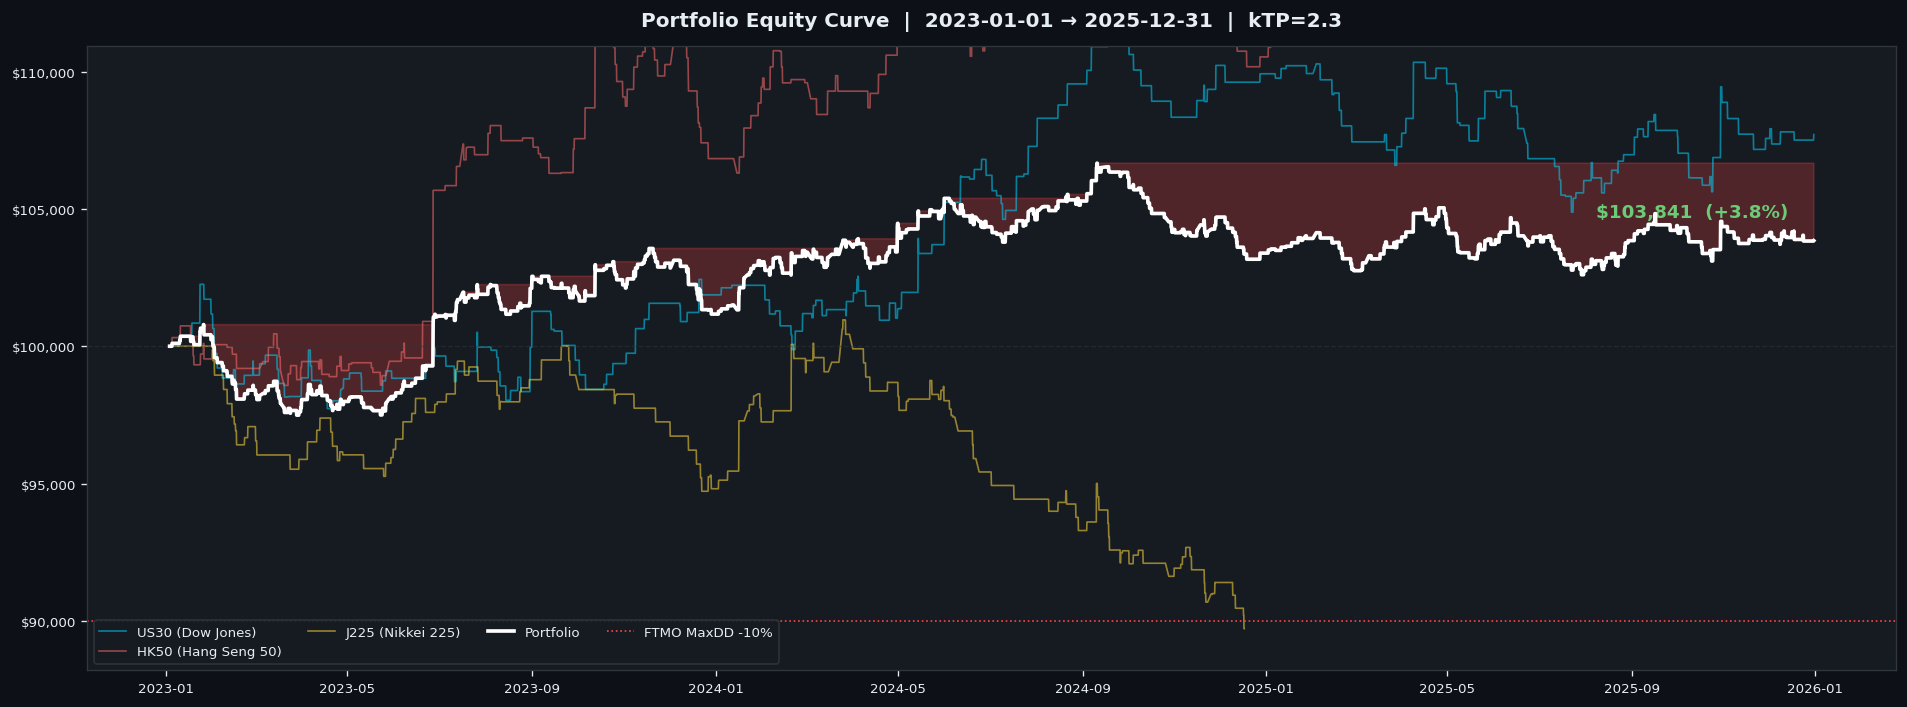

In [33]:
# ==============================================================================
# CELL 14 — EQUITY CURVE (ĐƯỜNG VỐN)
# ==============================================================================
#
## MỤC ĐÍCH
## Trực quan hóa quá trình tăng/giảm vốn theo thời gian để đánh giá tính ổn định
## của hệ thống, không chỉ nhìn một con số PnL cuối kỳ.
#
## THIẾT KẾ BIỂU ĐỒ
## - Tất cả đường equity (từng symbol và portfolio) đều được normalize về cùng
##   mặt bằng $100k để dễ so sánh hình dạng đường vốn giữa các symbol.
## - Vùng tô đỏ nhạt: drawdown portfolio (khoảng cách từ đỉnh đến vốn hiện tại).
## - Mốc FTMO MaxDD -10%: ngưỡng rủi ro tối đa theo rule tài khoản.

fig, ax = setup_dark_figure(figsize=(16, 6))

# Drawdown shading portfolio
peak = combined_equity.cummax()
ax.fill_between(
    combined_equity.index, combined_equity, peak,
    where=(combined_equity < peak), alpha=0.25, color=SIGNAL['sl']
)

# Per-symbol: normalize về INITIAL_BALANCE để cùng scale với portfolio
for idx, (sym, eq) in enumerate(equity_by_sym.items()):
    eq_clipped = eq[eq.index >= pd.Timestamp(DATE_FROM)]
    if eq_clipped.empty or eq_clipped.iloc[0] == 0:
        continue
    norm = eq_clipped / eq_clipped.iloc[0] * INITIAL_BALANCE  # scale lên $100k
    ax.plot(
        norm.index, norm,
        color=EQUITY_COLORS[idx % len(EQUITY_COLORS)],
        alpha=0.55, linewidth=1.0, label=TARGET_SYMBOLS[sym]['label']
    )

# Portfolio line
ax.plot(
    combined_equity.index, combined_equity,
    color='white', linewidth=2.2, label='Portfolio', zorder=5
)

# Mốc tham chiếu
ax.axhline(INITIAL_BALANCE, color=DARK['border'], linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(
    INITIAL_BALANCE * (1 - FTMO_MAX_DD),
    color=SIGNAL['sl'], linewidth=1, linestyle=':', label='FTMO MaxDD -10%'
)

# Y-axis: focus vào vùng thực tế có data (không để khoảng trống lớn)
y_min = INITIAL_BALANCE * (1 - FTMO_MAX_DD) * 0.98
y_max = combined_equity.max() * 1.04
ax.set_ylim(y_min, y_max)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Nhãn kết quả cuối kỳ
fe   = combined_equity.iloc[-1]
fret = (fe / INITIAL_BALANCE - 1) * 100
ax.annotate(
    f'${fe:,.0f}  ({fret:+.1f}%)',
    xy=(combined_equity.index[-1], fe), fontsize=11,
    color=SIGNAL['buy'] if fret >= 0 else SIGNAL['sell'], fontweight='bold',
    xytext=(-15, 14), textcoords='offset points', ha='right'
)

ax.set_title(
    f'Portfolio Equity Curve  |  {DATE_FROM} → {DATE_TO}  |  kTP={STRATEGY["ktp"]}',
    color=DARK['text'], fontsize=12, fontweight='bold', pad=12
)
ax.legend(
    loc='lower left', fontsize=8, facecolor=DARK['panel'],
    labelcolor=DARK['text'], framealpha=0.85, ncol=4, edgecolor=DARK['border']
)
plt.tight_layout()
plt.show()

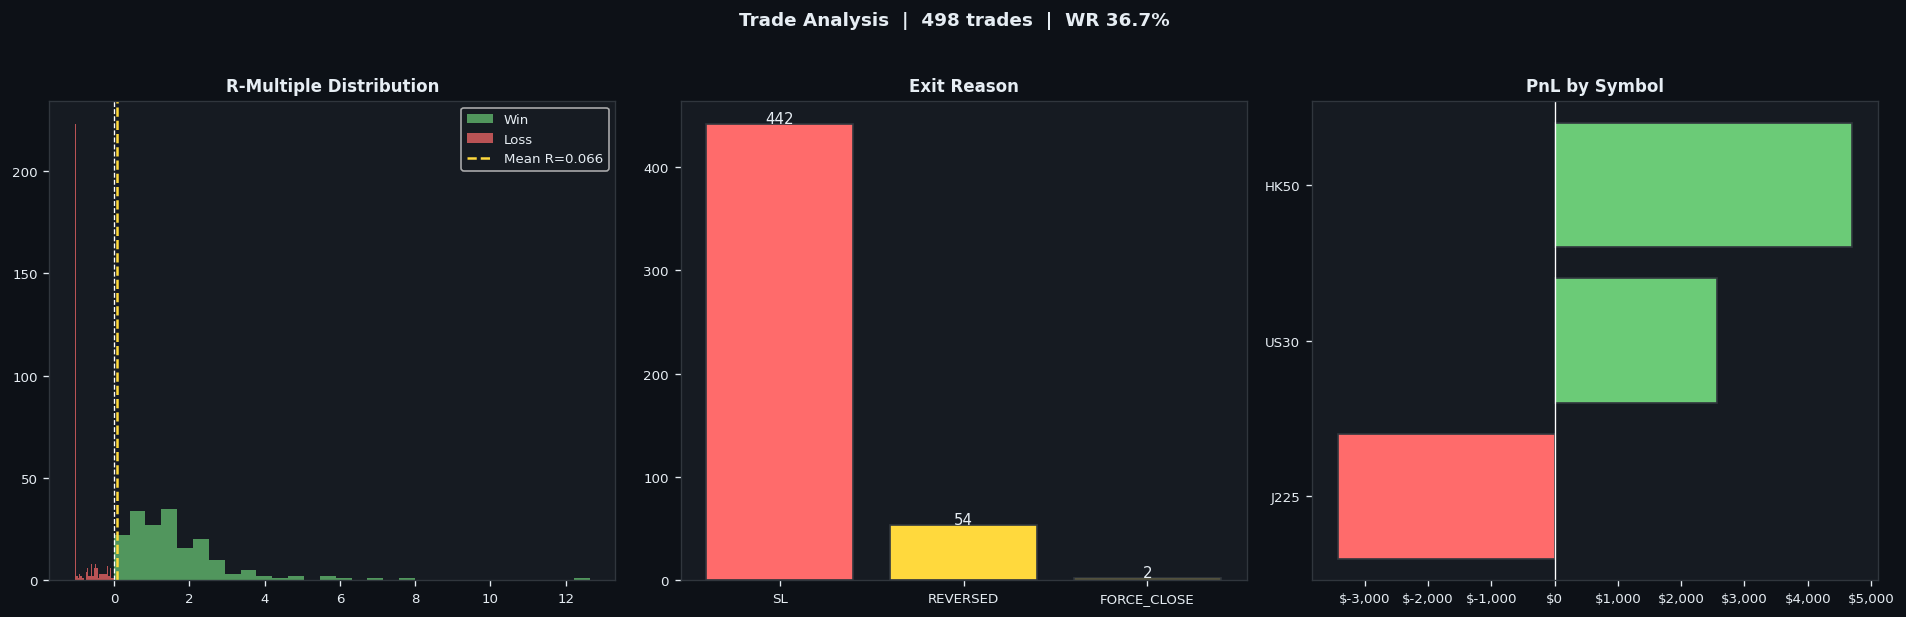

In [34]:
# ==============================================================================
# CELL 15 — PHÂN TÍCH CHẤT LƯỢNG LỆNH (TRADE ANALYSIS)
# ==============================================================================
#
## MỤC ĐÍCH
## Đi sâu vào hành vi lệnh để hiểu chiến lược thắng/thua như thế nào,
## thay vì chỉ nhìn con số tổng hợp cuối kỳ.
#
## 3 BIỂU ĐỒ TRONG CELL NÀY
## (1) R-Multiple Distribution: phân phối kết quả lệnh theo đơn vị R.
## (2) Exit Reason: lệnh thoát vì TP, SL hay lý do khác.
## (3) PnL by Symbol: symbol nào đóng góp/làm giảm lợi nhuận danh mục.
#
## VÌ SAO DÙNG R-MULTIPLE
## R giúp chuẩn hóa lợi nhuận/rủi ro theo mức risk ban đầu của lệnh,
## nhờ vậy bạn so sánh chất lượng lệnh công bằng hơn giữa các symbol.

tdf_all = pd.DataFrame(all_trades)

fig, axes = setup_dark_figure(1, 3, figsize=(16, 5))

# 1) R-multiple distribution
ax = axes[0]
wins_r = tdf_all[tdf_all['pnl_usd'] > 0]['r_multiple']
loss_r = tdf_all[tdf_all['pnl_usd'] <= 0]['r_multiple']
ax.hist(wins_r, bins=30, color=SIGNAL['buy'], alpha=0.7, label='Win')
ax.hist(loss_r, bins=30, color=SIGNAL['sell'], alpha=0.7, label='Loss')
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.axvline(
    tdf_all['r_multiple'].mean(),
    color=SIGNAL['ma_line'], linewidth=1.5, linestyle='--',
    label=f'Mean R={tdf_all["r_multiple"].mean():.3f}'
 )
ax.set_title('R-Multiple Distribution', color=DARK['text'], fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor=DARK['panel'], labelcolor=DARK['text'])

# 2) Exit reason
ax = axes[1]
exit_counts = tdf_all['exit_reason'].value_counts()
cols = [
    SIGNAL['buy'] if r == 'TP' else
    SIGNAL['sell'] if r == 'SL' else
    SIGNAL['ma_line']
    for r in exit_counts.index
]
bars = ax.bar(exit_counts.index, exit_counts.values, color=cols, edgecolor=DARK['border'])
for b, v in zip(bars, exit_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, str(v), ha='center', color=DARK['text'], fontsize=9)
ax.set_title('Exit Reason', color=DARK['text'], fontsize=10, fontweight='bold')

# 3) PnL per symbol
ax = axes[2]
sym_pnl = tdf_all.groupby('symbol')['pnl_usd'].sum().sort_values()
bar_cols = [SIGNAL['buy'] if v >= 0 else SIGNAL['sell'] for v in sym_pnl]
ax.barh(sym_pnl.index, sym_pnl.values, color=bar_cols, edgecolor=DARK['border'])
ax.axvline(0, color='white', linewidth=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('PnL by Symbol', color=DARK['text'], fontsize=10, fontweight='bold')

plt.suptitle(
    f'Trade Analysis  |  {len(tdf_all)} trades  |  WR {combined_metrics["win_rate"]}%',
    color=DARK['text'], fontsize=11, fontweight='bold', y=1.02
 )
plt.tight_layout()
plt.show()

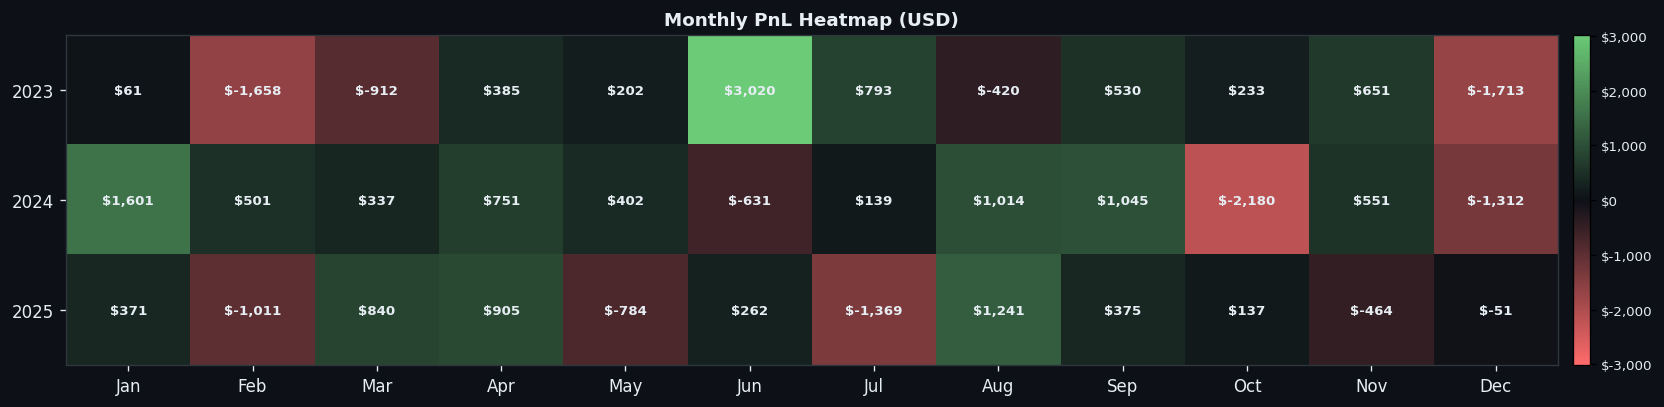

In [35]:
# ==============================================================================
# CELL 16 — MONTHLY PNL HEATMAP
# ==============================================================================
#
## MỤC ĐÍCH
## Gom lợi nhuận theo THÁNG để đánh giá tính ổn định theo thời gian (seasonality).
## Đây là góc nhìn quan trọng để phát hiện giai đoạn chiến lược hoạt động yếu/mạnh.
#
## CÁCH HIỂU MÀU
## - Xanh: tháng lãi
## - Đỏ : tháng lỗ
## - Màu càng đậm: biên độ USD càng lớn
#
## VÌ SAO CẦN HEATMAP
## Một chiến lược tốt không chỉ có tổng PnL dương, mà cần phân bổ lợi nhuận
## tương đối ổn qua nhiều tháng/năm, tránh phụ thuộc vài tháng "ăn may".

tdf_m = tdf_all.copy()
tdf_m['exit_time'] = pd.to_datetime(tdf_m['exit_time'])
tdf_m['yr'] = tdf_m['exit_time'].dt.year
tdf_m['mo'] = tdf_m['exit_time'].dt.month

# Pivot (year x month), ô trống điền 0 để bảng đủ 12 tháng
monthly = tdf_m.groupby(['yr', 'mo'])['pnl_usd'].sum().unstack(fill_value=0)
for m in range(1, 13):
    if m not in monthly.columns:
        monthly[m] = 0
monthly = monthly[sorted(monthly.columns)]

# Chuẩn hóa thang màu đối xứng quanh 0 để nhìn cân bằng lãi/lỗ
vmax = max(monthly.abs().values.max(), 1)
cmap = LinearSegmentedColormap.from_list(
    'rg', [SIGNAL['sell'], DARK['bg'], SIGNAL['buy']], N=256
)

fig, ax = setup_dark_figure(figsize=(14, 3.5))

im = ax.imshow(monthly.values, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
mo_lbls = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(range(len(monthly.columns)))
ax.set_xticklabels([mo_lbls[m - 1] for m in monthly.columns], color=DARK['text'], fontsize=10)
ax.set_yticks(range(len(monthly.index)))
ax.set_yticklabels([str(y) for y in monthly.index], color=DARK['text'], fontsize=10)

# In số USD trong từng ô để đọc nhanh mà không cần ước lượng màu
for yi, year in enumerate(monthly.index):
    for xi, mo in enumerate(monthly.columns):
        val = monthly.loc[year, mo]
        if val != 0:
            ax.text(
                xi, yi, f'${val:,.0f}', ha='center', va='center',
                fontsize=8, color=DARK['text'], fontweight='bold'
            )

cb = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))
cb.ax.tick_params(labelcolor=DARK['text'], labelsize=8)

ax.set_title('Monthly PnL Heatmap (USD)', color=DARK['text'], fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# ==============================================================================
# CELL 17 — EXPORT KẾT QUẢ (CSV + PNG + SUMMARY)
# ==============================================================================
#
## MỤC ĐÍCH
## Đóng gói kết quả backtest thành file để lưu trữ, đối chiếu và báo cáo.
## Sau cell này bạn có 2 đầu ra chính:
## - CSV trade log: dữ liệu chi tiết từng lệnh
## - PNG dashboard: ảnh tổng quan hiệu suất để review nhanh
#
## VÌ SAO CẦN EXPORT
## Notebook tiện để phân tích, nhưng file xuất mới phù hợp cho quy trình làm việc
## dài hạn: so sánh phiên bản chiến lược, gửi báo cáo, lưu audit trail.

import os
os.makedirs('output', exist_ok=True)

TRADELOG_FILE = f"output/backtest_trades_{DATE_FROM}_{DATE_TO}.csv"
CHART_FILE    = f"output/backtest_chart_{DATE_FROM}_{DATE_TO}.png"

# 1) Trade log: lưu toàn bộ lệnh để có thể kiểm tra lại từng trade khi cần
tdf_all.to_csv(TRADELOG_FILE, index=False, encoding='utf-8-sig')
print(f'✓ Trade log  → {TRADELOG_FILE}  ({len(tdf_all)} trades)')

# 2) Dashboard PNG: tạo một figure tổng hợp để mang đi báo cáo
fig2 = plt.figure(figsize=(20, 15), facecolor=DARK['bg'])
gs2  = gridspec.GridSpec(
    3, 3, figure=fig2, height_ratios=[2.4, 1.2, 1.2],
    hspace=0.5, wspace=0.35, top=0.96, bottom=0.07, left=0.06, right=0.98
)
fig2.suptitle(
    f'Combo Strategy  ·  H4  ·  {DATE_FROM}→{DATE_TO}  ·  kTP={STRATEGY["ktp"]}  ·  '
    f'WR {combined_metrics["win_rate"]}%  PF {combined_metrics["profit_factor"]}',
    fontsize=11, color=DARK['text'], fontweight='bold'
 )

# Equity subplot
ax_eq = fig2.add_subplot(gs2[0, :])
setup_dark_axes(ax_eq)
peak2 = combined_equity.cummax()
ax_eq.fill_between(
    combined_equity.index, combined_equity, peak2,
    where=(combined_equity < peak2), alpha=0.2, color=SIGNAL['sl']
 )
for idx, (sym, eq) in enumerate(equity_by_sym.items()):
    eq_c = eq[eq.index >= pd.Timestamp(DATE_FROM)]
    norm = eq_c / eq_c.iloc[0] * per_sym_bal
    ax_eq.plot(
        norm.index, norm,
        color=EQUITY_COLORS[idx % len(EQUITY_COLORS)], alpha=0.35,
        linewidth=0.9, label=TARGET_SYMBOLS[sym]['label']
    )
ax_eq.plot(combined_equity.index, combined_equity, color='white', linewidth=2, label='Portfolio')
ax_eq.axhline(INITIAL_BALANCE * (1 - FTMO_MAX_DD), color=SIGNAL['sl'], linewidth=0.8, linestyle=':')
ax_eq.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax_eq.legend(fontsize=7.5, facecolor=DARK['panel'], labelcolor=DARK['text'], ncol=5, framealpha=0.85)

plt.savefig(CHART_FILE, dpi=150, bbox_inches='tight', facecolor=DARK['bg'])
plt.close(fig2)
print(f'✓ Chart PNG  → {CHART_FILE}')

# 3) In final summary để chốt nhanh phiên backtest hiện tại
print()
print('=== FINAL SUMMARY ===')
for k, v in combined_metrics.items():
    print(f'  {k:<15}: {v}')

# ── Auto verdict ──────────────────────────────────────────────────────────────
portfolio_metrics = combined_metrics

pf_ok     = portfolio_metrics['profit_factor'] > 1.3
sharpe_ok = portfolio_metrics['sharpe'] > 1.0
dd_ok     = portfolio_metrics['max_drawdown'] > -20.0

verdict = 'PASS ✅' if all([pf_ok, sharpe_ok, dd_ok]) else 'FAIL ❌'
reasons = []
if not pf_ok:
    reasons.append(f"PF={portfolio_metrics['profit_factor']:.2f} < 1.3")
if not sharpe_ok:
    reasons.append(f"Sharpe={portfolio_metrics['sharpe']:.2f} < 1.0")
if not dd_ok:
    reasons.append(f"MaxDD={portfolio_metrics['max_drawdown']:.1f}% < -20%")

print(f"\n{'='*50}")
print(f"VERDICT: {verdict}")
if reasons:
    print(f"Lý do FAIL: {', '.join(reasons)}")
print(f"{'='*50}")


✓ Trade log  → output/backtest_trades_2023-01-01_2025-12-31.csv  (498 trades)
✓ Chart PNG  → output/backtest_chart_2023-01-01_2025-12-31.png

=== FINAL SUMMARY ===
  total_trades   : 498
  wins           : 183
  losses         : 315
  win_rate       : 36.7
  profit_factor  : 1.08
  total_pnl      : 3841.41
  total_return   : 3.84
  annual_return  : 1.27
  max_drawdown   : -3.81
  max_drawdown_usd: -4060.24
  sharpe         : 0.44
  sortino        : 0.45
  calmar         : 0.33
  recovery_factor: 0.95
  avg_win        : 285.99
  avg_loss       : -153.95
  total_swap_cost: -1209.66
  avg_rr         : 1.86
  avg_r          : 0.066
  partial_tp_trades: 144
  partial_tp_rate: 28.9
  monthly_pnl_table: month       1        2       3       4       5        6        7        8   \
year                                                                         
2023     60.55 -1657.70 -911.70  384.62  201.71  3019.87   792.95  -420.35   
2024   1601.10   501.37  337.50  750.89  402.08  -630.61   1